In [6]:
#!pip install TCT

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import TCT
from TCT import TCT_pathfinder
from TCT import TCT_neighborhood_finder

import matplotlib.pyplot as plt
import requests

In [7]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources(use_new_metakg_url=True)

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}


In [8]:
url = 'https://amlkg.systemsbiology.org:9990/AMLkg/meta_knowledge_graph'
response = requests.get(url, verify=False)
data = response.json()

for i in range(len(data["edges"])):
    APInames, metaKG = translator_metakg.add_new_API_for_query(APInames, metaKG, "AMLKG", "https://amlkg.systemsbiology.org:9990/AMLkg/query/", data["edges"][i]['predicate'], data["edges"][i]['subject'], data["edges"][i]['object'])

API_withMetaKG = list(set(metaKG['API']))
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))


/opt/miniconda3/envs/my-rdkit-env/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'amlkg.systemsbiology.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


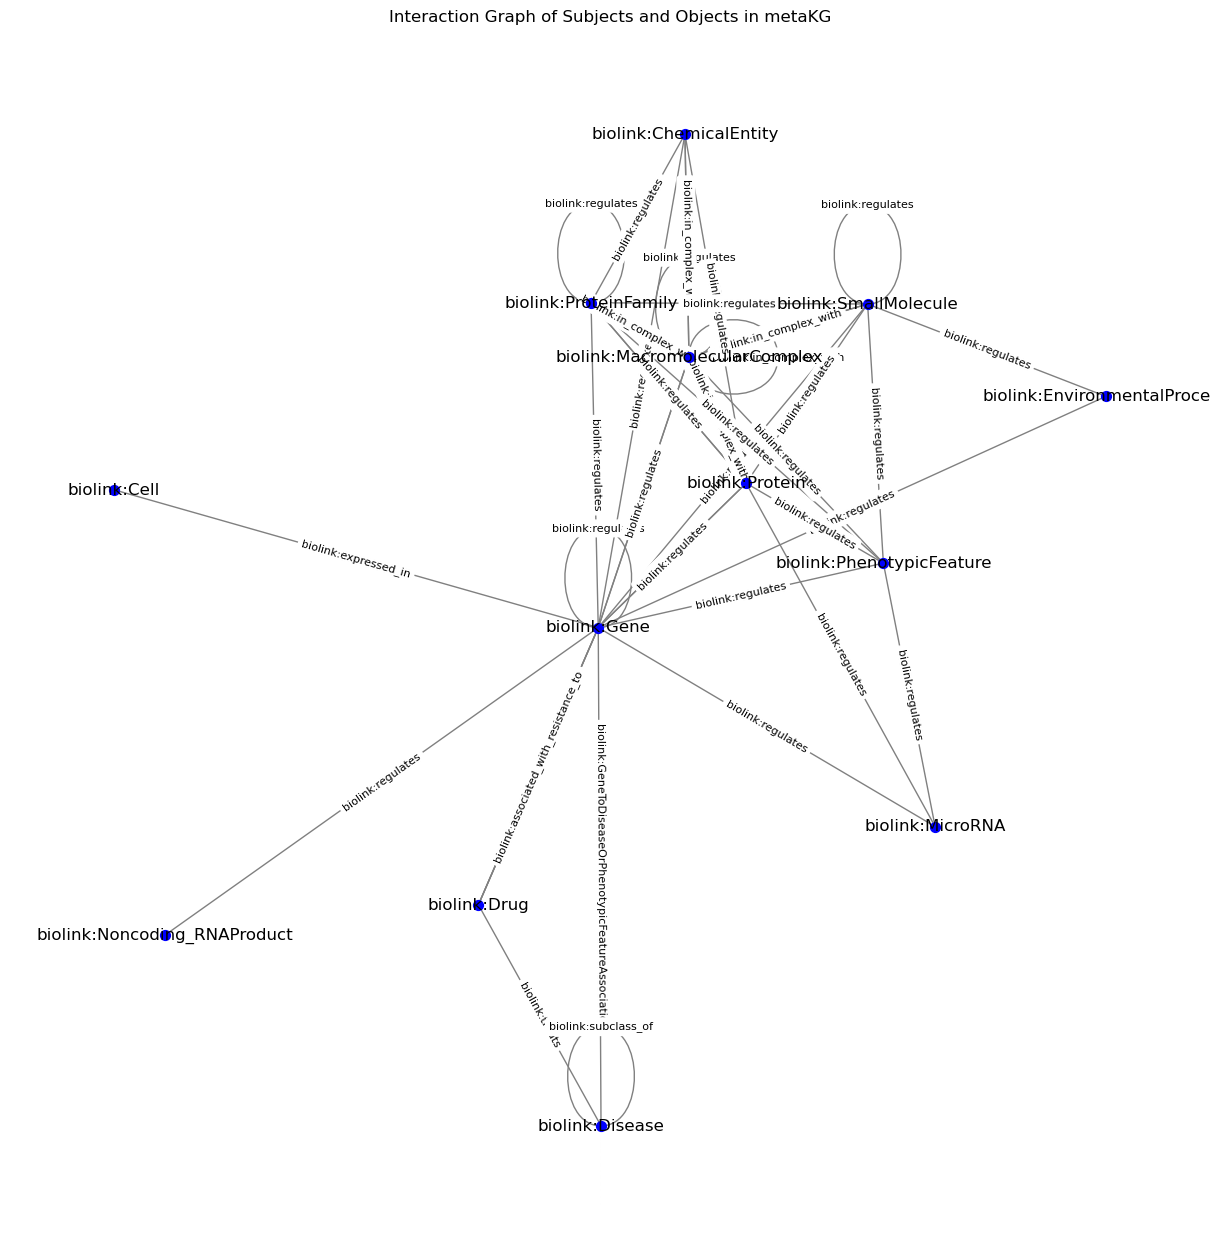

In [9]:
import networkx as nx
selected_KGs = ['AMLKG']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

# build a multigraph to capture all edges (including duplicates) and their predicates
G = nx.MultiGraph()
for _, row in metaKG_sele.iterrows():
        G.add_edge(row['Subject'], row['Object'], predicate=row['Predicate'])

# layout and draw nodes + edges
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos,
                with_labels=True,
                node_size=50,
                font_size=12,
                font_color='black',
                node_color='blue',
                edge_color='gray')

# draw edge labels
edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Interaction Graph of Subjects and Objects in metaKG')
plt.show()

In [10]:
# select a list of APIs to use and a list of predicates to use


selected_APIlist = ['AMLKG',
                    'Retriever',
                    'Clinical Trials KP - TRAPI 1.5.0',
                    'Drug Approvals KP - TRAPI 1.5.0',
                    'Genetics Data Provider for NCATS Biomedical Translator Reasoners',
                    #'Microbiome KP - TRAPI 1.5.0',
                    #'MolePro',
                    #'COHD TRAPI',
                    'RTX KG2 - TRAPI 1.5.0',
                    #'Text Mined Cooccurrence API',
                    'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0',
                    'CATRAX Pharmacogenomics KP - TRAPI 1.5.0',
                    ]

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)

{'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query/', 'Retriever': 'https://retriever.ci.transltr.io/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query'}
(11012, 5)


In [11]:
metaKG.loc[metaKG['API'] == 'AMLKG',['API','Predicate','Subject','Object']].drop_duplicates()

,API,Predicate,Subject,Object
26818,AMLKG,biolink:expressed_in,biolink:Gene,biolink:Cell
26819,AMLKG,biolink:regulates,biolink:Gene,biolink:Gene
26820,AMLKG,biolink:regulates,biolink:MacromolecularComplex,biolink:Gene
26821,AMLKG,biolink:regulates,biolink:MacromolecularComplex,biolink:PhenotypicFeature
26822,AMLKG,biolink:regulates,biolink:ChemicalEntity,biolink:Gene
26823,AMLKG,biolink:regulates,biolink:Protein,biolink:Gene
26824,AMLKG,biolink:regulates,biolink:Gene,biolink:MacromolecularComplex
26825,AMLKG,biolink:regulates,biolink:SmallMolecule,biolink:Gene
26826,AMLKG,biolink:regulates,biolink:SmallMolecule,biolink:SmallMolecule
26827,AMLKG,biolink:regulates,biolink:SmallMolecule,biolink:ProteinFamily


In [15]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')
subject_name = 'BCL2'
subject_node = name_resolver.lookup(subject_name, only_taxa='NCBITaxon:9606').curie

subject_category = name_resolver.lookup(subject_name).types
subject_category = ["biolink:Gene", "biolink:Protein"]

object_name = 'acute myeloid leukemia'
object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]

intermediate_categories = [ 'biolink:Drug','biolink:SmallMolecule','biolink:ChemicalSubstance','biolink:Gene','biolink:Protein']

In [19]:
subject_name = 'venetoclax'
subject_node = name_resolver.lookup(subject_name).curie
subject_node

'CHEBI:133021'

In [13]:
print(f"Subject: {subject_name}, CURIE: {subject_node}, Category: {subject_category}")
print(f"Object: {object_name}, CURIE: {object_node}, Category: {object_category}")

Subject: BCL2, CURIE: NCBIGene:596, Category: ['biolink:Gene', 'biolink:Protein']
Object: acute myeloid leukemia, CURIE: MONDO:0018874, Category: ['biolink:Disease']


In [ ]:
# test neighborhood finder by adding a new API to the metaKG
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT_neighborhood_finder.neighborhood_finder(subject_node,
                                                                                            #node2_categories = ['biolink:Drug','biolink:SmallMolecule','biolink:ChemicalSubstance'],
                                                                                            #node2_categories = ['biolink:AnatomicalEntity'],
                                                                                            node2_categories = ['biolink:Disease'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

TCT_neighborhood_finder_result = TCT_neighborhood_finder.parse_results_for_neighborhood_finder(subject_node, result,
        start_node_categories='biolink:Gene',
        end_node_categories=None,
        get_node_info=True,
        scoring_method='infores')

CHEBI:133021
Drug Approvals KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
NodeNorm does not know about these identifiers: UMLS:C5907820


In [17]:
input_identifiers = subject_node
import datetime
import json
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
with open('TCT_neighborhood_finder_result_'+input_identifiers.replace(':', '_')+'_'+timestamp+'.json', 'w') as f:
    json.dump(TCT_neighborhood_finder_result, f)

NCBIGene:596
MONDO:0018874
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
Genetics Data Provider for NCATS Biomedical Translator Reasoners: Success!
Drug Approvals KP - TRAPI 1.5.0: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!

Clinical Trials KP - TRAPI 1.5.0: Success!
NodeNorm does not know about these identifiers: DRUGBANK:DB15060,ttd.target:Indole-based_analog_3,ttd.target:Indole-based_analog_2,ttd.target:PMID27744724-Compound-18,ttd.target:BCL201,ttd.target:Oral_paclitaxel,ttd.target:PMID27744724-Compound-10,ttd.target:PMID27744724-Compound-21,ttd.target:Pc4_(topical_formulation,ttd.target:Liposomal_encapsulated_paclitaxel_(LEP),ttd.target:Irofulven/Taxotere,ttd.target:PI-88/Taxotere,ttd.target:Taxol/Paraplatin/Herceptin,orphanet:119007
NodeNorm does not know

/Users/gqin/Github_repo/Translator_component_toolkit/TCT/TCT.py:1653: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


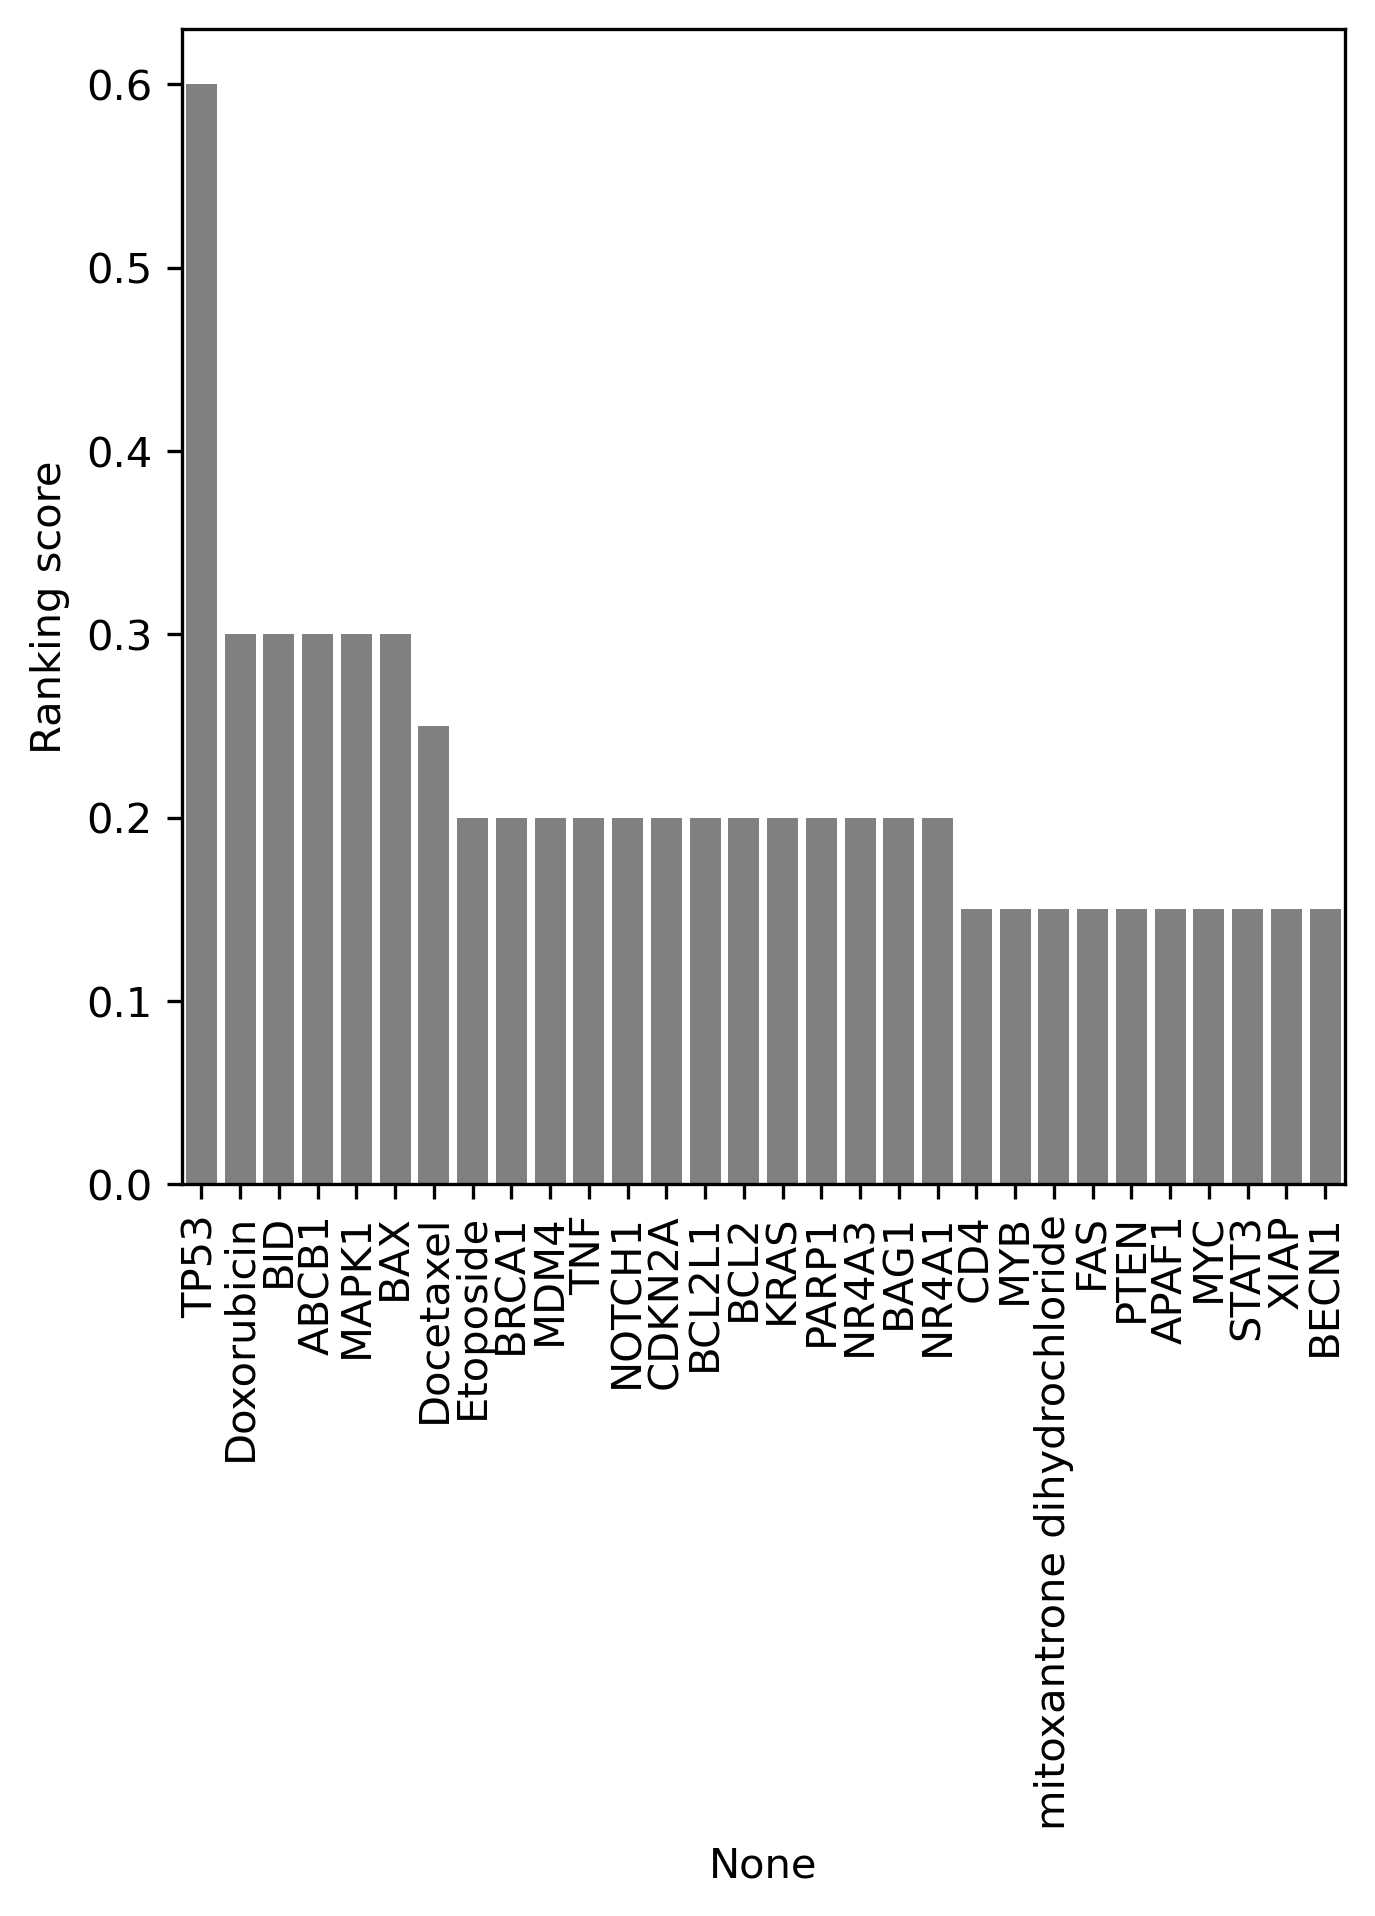

In [ ]:
# test pathfinder by adding a new API to the metaKG
result = TCT.Path_finder(input_node1=subject_node, #IFNG 
                         input_node2= object_node, #COVID-19
                         intermediate_categories=intermediate_categories, 
                         APInames=select_APIs, 
                         metaKG=selected_metaKG, 
                         API_predicates=API_predicates)

In [40]:
TCT_path_finder_result = TCT_pathfinder.parse_results_for_pathfinder(subject_node, object_node, result1=result['result1'], result2=result['result2'])
# return results path_finder_result to a json file
import json
with open(f'TCT_path_finder_result__{subject_node.replace(":", "_")}__{object_node.replace(":", "_")}.json', 'w') as f:
    json.dump(TCT_path_finder_result, f, indent=4)